In [1]:
import pandas as pd
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from tensorflow.keras.layers import LSTM, Dense, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import GRU, Input
from tensorflow.keras.models import Sequential
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

In [2]:
#data load
print(os.listdir("/kaggle/input/sepsis-detection-complex-dataset"))
healthcare_data = pd.read_csv("/kaggle/input/sepsis-detection-complex-dataset/Sepsis_Detection_Complex_Dataset.csv")

['Sepsis_Detection_Complex_Dataset.csv']


In [3]:
print(healthcare_data.head())  # Display first few rows
print(healthcare_data.info())  # Check columns and data types

   patient_id  age gender   bmi  comorbidities  heart_rate  blood_pressure  \
0           1   69   Male  22.5              2       106.3           145.3   
1           1   69   Male  22.5              2        89.1           116.8   
2           1   69   Male  22.5              2        60.9           135.5   
3           1   69   Male  22.5              2        92.6           126.1   
4           1   69   Male  22.5              2        67.6            97.6   

   oxygen_saturation  respiratory_rate  temperature  ...  lactate_levels  \
0               93.6              21.0         36.4  ...            1.34   
1               89.3              17.6         36.1  ...            2.70   
2               92.0              17.0         36.3  ...            2.17   
3               94.6              23.3         36.8  ...            2.48   
4               87.9              23.0         36.6  ...            3.14   

    crp  creatinine  platelet_count  procalcitonin  sofa_score  qsofa_scor

In [4]:
# Handle missing values (forward fill for time-series data)
healthcare_data = healthcare_data.ffill()

In [5]:
# Convert column names to lowercase
healthcare_data.columns = healthcare_data.columns.str.lower()

# Select only available features
features = [
    'age', 'bmi', 'comorbidities', 'heart_rate', 'blood_pressure', 'oxygen_saturation', 
    'respiratory_rate', 'temperature', 'wbc_count', 'lactate_levels', 'crp', 'creatinine',
    'platelet_count', 'procalcitonin', 'sofa_score', 'qsofa_score', 'mechanical_ventilation', 'vasopressor_use'
]
X = healthcare_data[features]

# Select target label
y = healthcare_data['sepsis_label']  # Ensure 'label' column exists


In [6]:
# Create time windows for LSTM/GRU processing
window_size = 48  # Adjust based on data resolution
X_windows, y_windows = [], []
for i in range(len(X) - window_size + 1):
    X_windows.append(X.iloc[i:i+window_size].values)
    y_windows.append(y.iloc[i+window_size-1])

X_windows = np.array(X_windows)
y_windows = np.array(y_windows)

In [7]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_windows, y_windows, test_size=0.2, random_state=42)

In [8]:
# Normalize data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.reshape(-1, X_train.shape[-1])).reshape(X_train.shape)
X_test_scaled = scaler.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam

# Initialize the model
model_lstm = Sequential()

# Input Layer
model_lstm.add(Input(shape=(window_size, len(features))))  

# First LSTM Layer (More Units + Dropout)
model_lstm.add(LSTM(units=64, return_sequences=True))
model_lstm.add(Dropout(0.3))  

# Second LSTM Layer (Lower Units)
model_lstm.add(LSTM(units=32))
model_lstm.add(Dropout(0.3))

# Output Layer
model_lstm.add(Dense(1, activation='sigmoid'))  # Sigmoid for binary classification

# Compile Model (Using a Lower Learning Rate for Stability)
optimizer = Adam(learning_rate=0.0005)  
model_lstm.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

# Print model summary
model_lstm.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 48, 64)              │          21,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 48, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 33,697 (131.63 KB)

 Trainable params: 33,697 (131.63 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam

# Initialize GRU model
model_gru = Sequential()

# Input Layer
model_gru.add(Input(shape=(window_size, len(features))))  

# First GRU Layer (More Units + Dropout)
model_gru.add(GRU(units=64, return_sequences=True))
model_gru.add(Dropout(0.3))  

# Second GRU Layer (Lower Units + Dropout)
model_gru.add(GRU(units=32))
model_gru.add(Dropout(0.3))

# Output Layer
model_gru.add(Dense(1, activation='sigmoid'))  # Sigmoid for binary classification

# Compile the model (Lower Learning Rate for Stability)
optimizer = Adam(learning_rate=0.0005)  
model_gru.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

# Print model summary
model_gru.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru (GRU)                            │ (None, 48, 64)              │          16,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 48, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_1 (GRU)                          │ (None, 32)                  │           9,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 25,569 (99.88 KB)

 Trainable params: 25,569 (99.88 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Train the models
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history_lstm = model_lstm.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_split=0.2, callbacks=[early_stopping])
history_gru = model_gru.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_split=0.2, callbacks=[early_stopping])

Epoch 1/50
4800/4800 ━━━━━━━━━━━━━━━━━━━━ 162s 33ms/step - accuracy: 0.9377 - loss: 0.1776 - val_accuracy: 0.9653 - val_loss: 0.0789
Epoch 2/50
4800/4800 ━━━━━━━━━━━━━━━━━━━━ 160s 33ms/step - accuracy: 0.9668 - loss: 0.0786 - val_accuracy: 0.9788 - val_loss: 0.0501
Epoch 3/50
4800/4800 ━━━━━━━━━━━━━━━━━━━━ 161s 33ms/step - accuracy: 0.9773 - loss: 0.0535 - val_accuracy: 0.9865 - val_loss: 0.0330
Epoch 4/50
4800/4800 ━━━━━━━━━━━━━━━━━━━━ 160s 33ms/step - accuracy: 0.9828 - loss: 0.0403 - val_accuracy: 0.9881 - val_loss: 0.0265
Epoch 5/50
4800/4800 ━━━━━━━━━━━━━━━━━━━━ 160s 33ms/step - accuracy: 0.9859 - loss: 0.0326 - val_accuracy: 0.9919 - val_loss: 0.0198
Epoch 6/50
4800/4800 ━━━━━━━━━━━━━━━━━━━━ 161s 34ms/step - accuracy: 0.9881 - loss: 0.0280 - val_accuracy: 0.9931 - val_loss: 0.0179
Epoch 7/50
4800/4800 ━━━━━━━━━━━━━━━━━━━━ 160s 33ms/step - accuracy: 0.9899 - loss: 0.0237 - val_accuracy: 0.9930 - val_loss: 0.0164
Epoch 8/50
4800/4800 ━━━━━━━━━━━━━━━━━━━━ 161s 34ms/step - accuracy: 

In [12]:
# Make predictions
y_pred_lstm = model_lstm.predict(X_test_scaled)
y_pred_gru = model_gru.predict(X_test_scaled)

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step


In [13]:
# Convert probabilities to binary predictions
y_pred_lstm_binary = (y_pred_lstm > 0.5).astype(int)
y_pred_gru_binary = (y_pred_gru > 0.5).astype(int)

In [14]:
# Calculate performance metrics
metrics = {
    "LSTM": {
        "accuracy": accuracy_score(y_test, y_pred_lstm_binary),
        "precision": precision_score(y_test, y_pred_lstm_binary),
        "recall": recall_score(y_test, y_pred_lstm_binary),
        "f1_score": f1_score(y_test, y_pred_lstm_binary),
        "roc_auc": roc_auc_score(y_test, y_pred_lstm)
    },
    "GRU": {
        "accuracy": accuracy_score(y_test, y_pred_gru_binary),
        "precision": precision_score(y_test, y_pred_gru_binary),
        "recall": recall_score(y_test, y_pred_gru_binary),
        "f1_score": f1_score(y_test, y_pred_gru_binary),
        "roc_auc": roc_auc_score(y_test, y_pred_gru)
    }
}

In [15]:
# Print performance results
for model, scores in metrics.items():
    print(f"{model} Model Performance:")
    for metric, value in scores.items():
        print(f"  {metric}: {value:.4f}")
    print()

LSTM Model Performance:
  accuracy: 0.9965
  precision: 0.9777
  recall: 0.9777
  f1_score: 0.9777
  roc_auc: 0.9999

GRU Model Performance:
  accuracy: 0.9662
  precision: 0.7886
  recall: 0.7695
  f1_score: 0.7790
  roc_auc: 0.9873



In [16]:
# Evaluate performance
print("LSTM AUC-ROC:", roc_auc_score(y_test, y_pred_lstm))
print("GRU AUC-ROC:", roc_auc_score(y_test, y_pred_gru))
print("LSTM Accuracy:", accuracy_score(y_test, y_pred_lstm_binary))
print("GRU Accuracy:", accuracy_score(y_test, y_pred_gru_binary))
print("LSTM Precision:", precision_score(y_test, y_pred_lstm_binary))
print("GRU Precision:", precision_score(y_test, y_pred_gru_binary))
print("LSTM Recall:", recall_score(y_test, y_pred_lstm_binary))
print("GRU Recall:", recall_score(y_test, y_pred_gru_binary))
print("LSTM F1-score:", f1_score(y_test, y_pred_lstm_binary))
print("GRU F1-score:", f1_score(y_test, y_pred_gru_binary))

LSTM AUC-ROC: 0.9998646658150494
GRU AUC-ROC: 0.9873440554007742
LSTM Accuracy: 0.9965410181075618
GRU Accuracy: 0.9662019962076223
LSTM Precision: 0.977652127086699
GRU Precision: 0.7886313465783664
LSTM Recall: 0.977652127086699
GRU Recall: 0.769520732364028
LSTM F1-score: 0.977652127086699
GRU F1-score: 0.7789588443717634


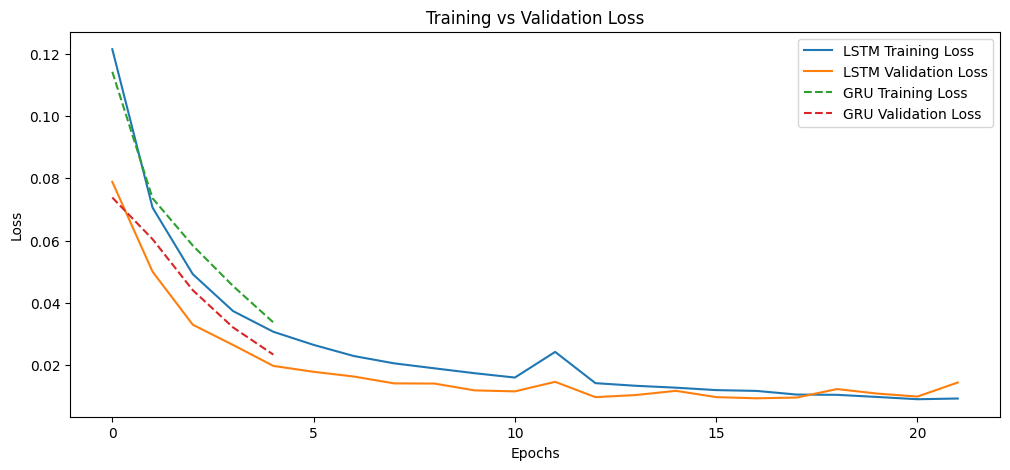

In [17]:
# Visualization
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.plot(history_lstm.history['loss'], label='LSTM Training Loss')
plt.plot(history_lstm.history['val_loss'], label='LSTM Validation Loss')
plt.plot(history_gru.history['loss'], label='GRU Training Loss', linestyle='dashed')
plt.plot(history_gru.history['val_loss'], label='GRU Validation Loss', linestyle='dashed')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

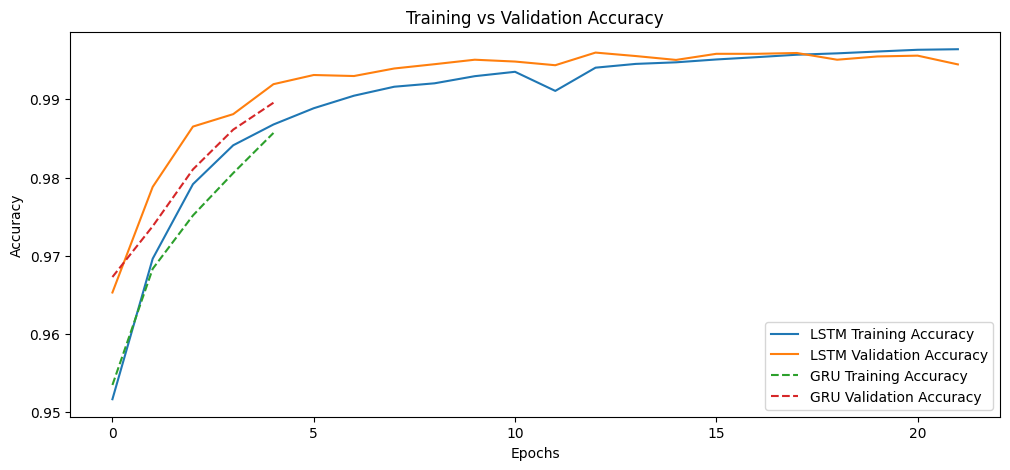

In [18]:
plt.figure(figsize=(12, 5))
plt.plot(history_lstm.history['accuracy'], label='LSTM Training Accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='LSTM Validation Accuracy')
plt.plot(history_gru.history['accuracy'], label='GRU Training Accuracy', linestyle='dashed')
plt.plot(history_gru.history['val_accuracy'], label='GRU Validation Accuracy', linestyle='dashed')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step


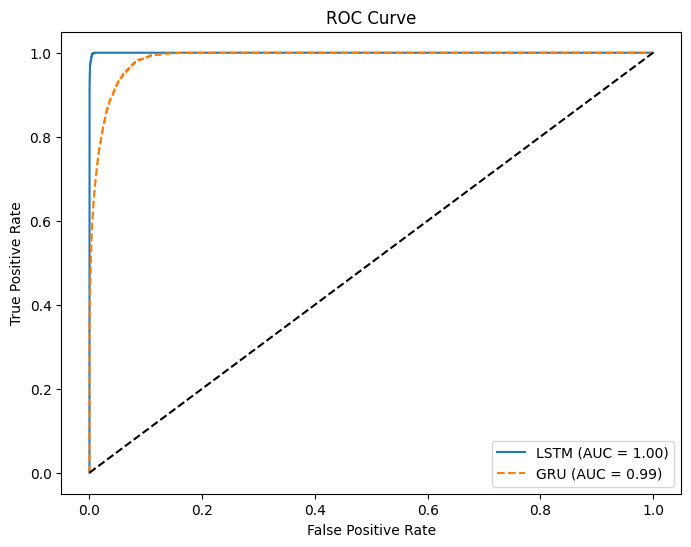

In [19]:
from sklearn.metrics import roc_curve, auc

# Get LSTM predictions
y_pred_lstm_prob = model_lstm.predict(X_test_scaled)
fpr_lstm, tpr_lstm, _ = roc_curve(y_test, y_pred_lstm_prob)
roc_auc_lstm = auc(fpr_lstm, tpr_lstm)

# Get GRU predictions
y_pred_gru_prob = model_gru.predict(X_test_scaled)
fpr_gru, tpr_gru, _ = roc_curve(y_test, y_pred_gru_prob)
roc_auc_gru = auc(fpr_gru, tpr_gru)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_lstm, tpr_lstm, label=f"LSTM (AUC = {roc_auc_lstm:.2f})")
plt.plot(fpr_gru, tpr_gru, label=f"GRU (AUC = {roc_auc_gru:.2f})", linestyle="dashed")

plt.plot([0, 1], [0, 1], 'k--')  # Random model line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


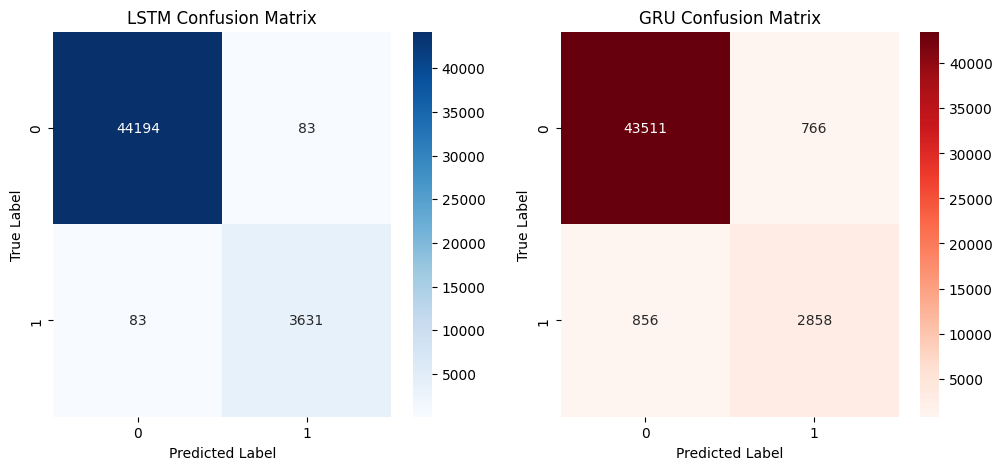

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Convert probabilities to binary
y_pred_lstm_binary = (y_pred_lstm_prob > 0.5).astype(int)
y_pred_gru_binary = (y_pred_gru_prob > 0.5).astype(int)

# Compute confusion matrix
cm_lstm = confusion_matrix(y_test, y_pred_lstm_binary)
cm_gru = confusion_matrix(y_test, y_pred_gru_binary)

# Plot confusion matrix
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_lstm, annot=True, fmt="d", cmap="Blues", ax=ax[0])
ax[0].set_title("LSTM Confusion Matrix")
ax[0].set_xlabel("Predicted Label")
ax[0].set_ylabel("True Label")

sns.heatmap(cm_gru, annot=True, fmt="d", cmap="Reds", ax=ax[1])
ax[1].set_title("GRU Confusion Matrix")
ax[1].set_xlabel("Predicted Label")
ax[1].set_ylabel("True Label")

plt.show()
